# 🗄️ Customer Retention Analysis — SQL Analysis
**Tools:** Python, SQLite, Pandas  
**Goal:** Answer key business questions about churn using SQL queries

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="Set2")

print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Load Data into SQLite Database

In [2]:
# Load CSV
df = pd.read_csv('../data/telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Push into SQLite
conn = sqlite3.connect('../data/telco_churn.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

print(f"✅ Loaded {len(df)} records into SQLite")
print("📌 Table: customers")

✅ Loaded 7043 records into SQLite
📌 Table: customers


In [3]:
def run_query(sql, title=""):
    result = pd.read_sql_query(sql, conn)
    if title:
        print(f"\n{'='*50}")
        print(f"📊 {title}")
        print(f"{'='*50}")
    return result

## 2. Business Question 1 — What is the overall churn rate?

In [4]:
q1 = run_query("""
    SELECT 
        COUNT(*) AS total_customers,
        SUM(Churn_Binary) AS churned_customers,
        ROUND(AVG(Churn_Binary) * 100, 2) AS churn_rate_pct
    FROM customers
""", "Overall Churn Rate")

display(q1)
print("📌 Insight: Roughly 1 in 4 customers churns — a significant revenue risk.")


📊 Overall Churn Rate


,total_customers,churned_customers,churn_rate_pct
0,7043,1869,26.54


📌 Insight: Roughly 1 in 4 customers churns — a significant revenue risk.


## 3. Business Question 2 — Which contract type has the highest churn?


📊 Churn Rate by Contract Type


,Contract,total_customers,churned,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


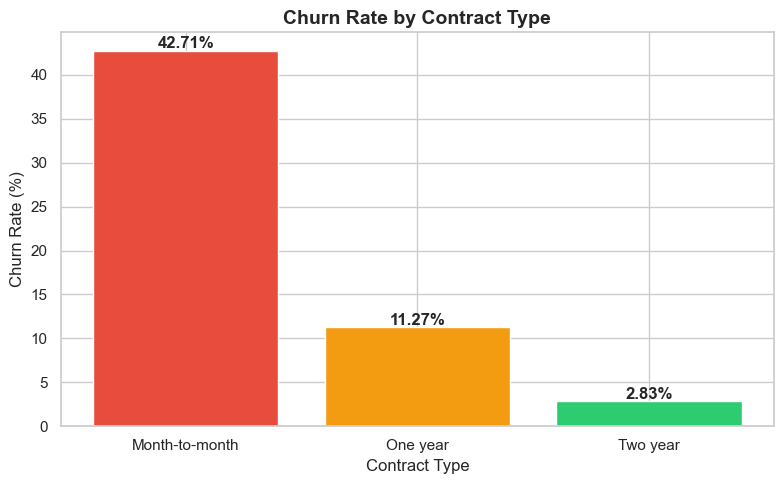

📌 Insight: Month-to-month customers churn at 42.7% vs only 2.8% for two-year contracts.


In [5]:
q2 = run_query("""
    SELECT 
        Contract,
        COUNT(*) AS total_customers,
        SUM(Churn_Binary) AS churned,
        ROUND(AVG(Churn_Binary) * 100, 2) AS churn_rate_pct
    FROM customers
    GROUP BY Contract
    ORDER BY churn_rate_pct DESC
""", "Churn Rate by Contract Type")

display(q2)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(q2['Contract'], q2['churn_rate_pct'],
               color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
for bar, val in zip(bars, q2['churn_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/sql_contract_churn.png', bbox_inches='tight', dpi=150)
plt.show()

print("📌 Insight: Month-to-month customers churn at 42.7% vs only 2.8% for two-year contracts.")

## 4. Business Question 3 — What is the revenue lost due to churn?

In [7]:
q3 = run_query("""
    SELECT
        Churn,
        COUNT(*) AS customers,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
        ROUND(SUM(MonthlyCharges), 2) AS total_monthly_revenue
    FROM customers
    GROUP BY Churn
""", "Revenue Impact of Churn")

display(q3)

churned_rev = q3[q3['Churn'] == 'Yes']['total_monthly_revenue'].values[0]
print(f"\n💸 Monthly revenue lost to churn: ${churned_rev:,.2f}")
print(f"💸 Estimated annual revenue lost: ${churned_rev * 12:,.2f}")


📊 Revenue Impact of Churn


,Churn,customers,avg_monthly_charges,total_monthly_revenue
0,No,5174,61.27,316985.75
1,Yes,1869,74.44,139130.85



💸 Monthly revenue lost to churn: $139,130.85
💸 Estimated annual revenue lost: $1,669,570.20


## 5. Business Question 4 — Which payment method has the highest churn?


📊 Churn Rate by Payment Method


,PaymentMethod,total_customers,churn_rate_pct
0,Electronic check,2365,45.29
1,Mailed check,1612,19.11
2,Bank transfer (automatic),1544,16.71
3,Credit card (automatic),1522,15.24


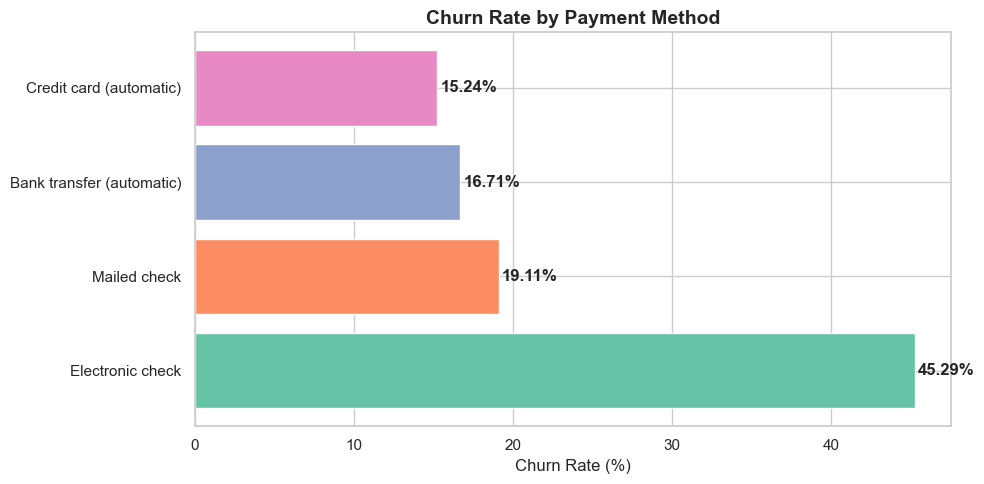

📌 Insight: Electronic check users churn at 45% — highest of all payment methods.


In [8]:
q4 = run_query("""
    SELECT 
        PaymentMethod,
        COUNT(*) AS total_customers,
        ROUND(AVG(Churn_Binary) * 100, 2) AS churn_rate_pct
    FROM customers
    GROUP BY PaymentMethod
    ORDER BY churn_rate_pct DESC
""", "Churn Rate by Payment Method")

display(q4)

plt.figure(figsize=(10, 5))
bars = plt.barh(q4['PaymentMethod'], q4['churn_rate_pct'],
                color=sns.color_palette("Set2", len(q4)), edgecolor='white')
plt.title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Churn Rate (%)')
for bar, val in zip(bars, q4['churn_rate_pct']):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/sql_payment_churn.png', bbox_inches='tight', dpi=150)
plt.show()

print("📌 Insight: Electronic check users churn at 45% — highest of all payment methods.")

## 6. Business Question 5 — Who are the high-value customers at risk of churning?

In [9]:
q5 = run_query("""
    SELECT 
        customerID,
        tenure,
        MonthlyCharges,
        TotalCharges,
        Contract,
        PaymentMethod
    FROM customers
    WHERE Churn = 'Yes'
        AND MonthlyCharges > 70
        AND tenure < 12
    ORDER BY MonthlyCharges DESC
    LIMIT 10
""", "High-Value Customers Who Already Churned (Early + High Spend)")

display(q5)
print("📌 These customers paid premium prices but left within the first year — highest priority for retention programs.")


📊 High-Value Customers Who Already Churned (Early + High Spend)


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod
0,9851-KIELU,10,110.10,1043.30,Month-to-month,Electronic check
1,3992-YWPKO,6,109.90,669.45,Month-to-month,Credit card (automatic)
2,1400-MMYXY,3,105.90,334.65,Month-to-month,Electronic check
3,3932-CMDTD,4,105.65,443.90,One year,Electronic check
4,3389-YGYAI,8,105.50,829.55,Month-to-month,Electronic check
5,5052-PNLOS,3,105.35,323.25,Month-to-month,Bank transfer (automatic)
6,4587-VVTOX,6,105.30,545.20,Month-to-month,Electronic check
7,6496-SLWHQ,3,105.00,294.45,Month-to-month,Electronic check
8,1875-QIVME,2,104.40,242.80,Month-to-month,Electronic check
9,5923-GXUOC,10,104.40,1081.45,Month-to-month,Electronic check


📌 These customers paid premium prices but left within the first year — highest priority for retention programs.


## 7. Business Question 6 — Does having TechSupport reduce churn?


📊 Impact of TechSupport on Churn


,TechSupport,total_customers,churn_rate_pct
0,No,3473,41.64
1,Yes,2044,15.17


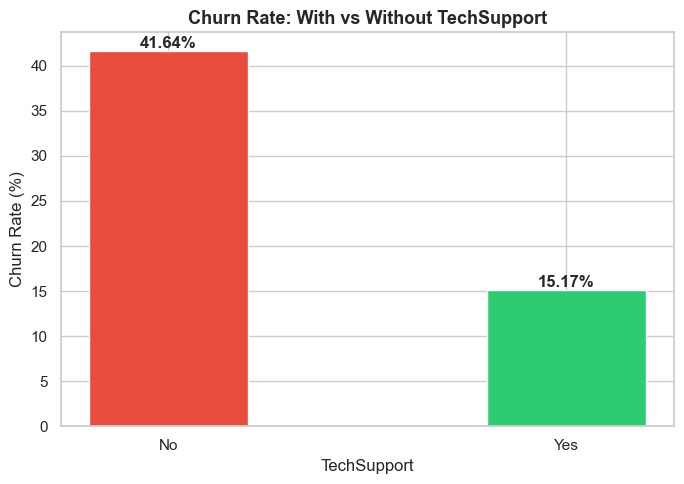

📌 Insight: Customers without TechSupport churn at 2x the rate — bundling it reduces churn significantly.


In [10]:
q6 = run_query("""
    SELECT 
        TechSupport,
        COUNT(*) AS total_customers,
        ROUND(AVG(Churn_Binary) * 100, 2) AS churn_rate_pct
    FROM customers
    WHERE TechSupport != 'No internet service'
    GROUP BY TechSupport
    ORDER BY churn_rate_pct DESC
""", "Impact of TechSupport on Churn")

display(q6)

plt.figure(figsize=(7, 5))
bars = plt.bar(q6['TechSupport'], q6['churn_rate_pct'],
               color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
plt.title('Churn Rate: With vs Without TechSupport', fontsize=13, fontweight='bold')
plt.xlabel('TechSupport')
plt.ylabel('Churn Rate (%)')
for bar, val in zip(bars, q6['churn_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/sql_techsupport_churn.png', bbox_inches='tight', dpi=150)
plt.show()

print("📌 Insight: Customers without TechSupport churn at 2x the rate — bundling it reduces churn significantly.")

## 8. 🔑 SQL Analysis Summary

| Business Question | Key Finding |
|---|---|
| Overall churn rate | ~26.5% of customers churn |
| Contract type | Month-to-month: 42.7% churn vs Two-year: 2.8% |
| Revenue lost | ~$139K/month, ~$1.67M/year |
| Payment method | Electronic check users churn at 45% |
| High-value at-risk | High spenders with <12 months tenure are priority |
| TechSupport impact | No TechSupport = 2x higher churn rate |

> **Next:** ML Churn Prediction → `03_ML_Model.ipynb`